
```bash
#! pip install -r requirements.txt
```

## 目录：

- 数值计算与符号计算
    - numpy 简介
    - sympy 符号计算简介
- matplotlib 可视化简介
- Python 处理 Office 文件简介
- Python 处理网络数据简介


## 1. numpy 简介

- numpy 是 Numerical Python 的缩写，是 Python 科学计算最重要的基础软件包之一，大多数提供科学功能的计算包都使用 numpy 的数组对象作为数据交换的通用语言。
- numpy中的数组对象（`ndarray`）是一个高效的多维数组类，提供面向数组的快速算术运算和灵活的广播（broadcasting）功能。有大量可用于对整个数据数组进行快速运算的数学函数，因此通常无需编写循环结构。
- numpy 还包含线性代数、随机数生成和傅立叶变换等功能，可与 scipy 库结合，完成更丰富的科学计算任务。


In [1]:
import numpy as np

### numpy 数组创建

|        函数        	        |          功能描述                          	           |
|:-------------------------:|:--------------------------------------------------:|
|  `array`               	  |       将输入数据（列表、元组、数组或其他序列类型）转换为`ndarray`  	        |
|  `arange`              	  | 与Python内置 `range` 函数类似，但返回数组                     	 |
| `ones`,   `ones_like`   	 |  产生一个所有元素为 1 的数组                                	  |
| `zeros`,   `zeros_like` 	 |  产生一个所有元素为 0 的数组                                	  |
| `eye`,   `identity`     	 |       创建一个 N 行 N 列的单位矩阵（对角线元素为 1，其他为   0） 	        |

In [2]:
# 从列表、元组、数组或其他序列类型创建数组
a1 = np.array([1,1,2,3,5,8])
a1

array([1, 1, 2, 3, 5, 8])

In [3]:
# 创建一个“区间”（与Python内置的range函数类似，但返回数组）
a2 = np.arange(1,10,2)
a2

array([1, 3, 5, 7, 9])

In [4]:
# 产生一个所有元素为 1 的数组, 接收元组参数
a3 = np.ones((5,3))     # 5行、3列
a3

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [5]:
# 产生一个所有元素为 0 的数组, 接收元组参数
a4 = np.zeros((4,2))    # 4行、2列
a4

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [6]:
# 创建一个单位矩阵（对角线元素为 1，其他为 0）, 可接收整数参数
a5 = np.eye(4)      # 4行4列
a5

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

### numpy.ndarray 与 list 对比

- 列表（`list`）：数据类型可变，灵活性很好，但代价是列表中的每一项都必须包含自己的类型信息、引用计数等信息，效率较低；
- 数组（`ndarray`）：数据类型一致，数据存储在连续内存中，效率较高。


<img src="./images/list-vs-array.png" width="80%">

In [7]:
b1 = np.arange(1000000)
b2 = list(range(1000000))

接下来：计算列表/数组中每一项元素的立方，并用`%timeit`命令估算运行所需时间

In [8]:
# 数组与常数的运算 == 数组的每一个元素与常数进行相应运算，并返回运算后的数组 
%timeit b1**2

977 µs ± 16.3 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [9]:
%timeit [x**2 for x in b2]

217 ms ± 4.38 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### numpy 数组的大小、维度与形状

- 通过`size`属性查看数组的大小
- 通过`ndim`属性查看数组对象的维度
- 通过`shape`属性查看数组对象的形状
- 通过`reshape()`方法或借助`np.newaxis`改变数组维度与形状
- 通过`transpose()`函数交换数组在不同维度的尺寸；对于二维数组，可以实现将行列互换，类似矩阵的转置操作。

In [10]:
a1 = np.arange(20)
a2 = a1.reshape(4,5)

print("a1: size={}, ndim={}, shape={}".format(a1.size, a1.ndim, a1.shape))
print("a2: size={}, ndim={}, shape={}".format(a2.size, a2.ndim, a2.shape))

a1: size=20, ndim=1, shape=(20,)
a2: size=20, ndim=2, shape=(4, 5)


`np.newaxis` 简介

In [11]:
np.newaxis == None

True

In [12]:
a1_with_newaxis = a1[:, np.newaxis]     # 扩充维度
print("a1_new: size={}, ndim={}, shape={}".format(
    a1_with_newaxis.size, a1_with_newaxis.ndim, a1_with_newaxis.shape))

a1_new: size=20, ndim=2, shape=(20, 1)


`np.newaxis` 可用于增维度，与之相对地，可以使用`squeeze()`方法降低维度

In [13]:
a1_with_newaxis.squeeze()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

通过`transpose()`实现矩阵的转置操作


In [14]:
a2

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

In [15]:
a2.transpose()  # 等价语句：a2.T

array([[ 0,  5, 10, 15],
       [ 1,  6, 11, 16],
       [ 2,  7, 12, 17],
       [ 3,  8, 13, 18],
       [ 4,  9, 14, 19]])

### numpy 数组的索引与切片

- 数组的索引与切片规则与列表类似
    - 索引下标从0开始
    - 切片的区间是前闭后开区间
- 对于多维数组，索引可以有两种表示方法


In [16]:
a2 = np.arange(12).reshape(3,4)
a2

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [17]:
"a2[0,0] = {}, a2[0][0] = {}, a2[2,-1] = {}".format(a2[0,0],a2[0][0],a2[2,-1])

'a2[0,0] = 0, a2[0][0] = 0, a2[2,-1] = 11'

In [18]:
a2[1:3, 0:2] 

array([[4, 5],
       [8, 9]])

### numpy 数组与常数运算

数组与常数之间的加、减、乘、除、乘方等运算，其作用效果相当于将数组中的**每个元素**与常数进行相应运算，并返回运算后的数组。

In [19]:
a2 = np.arange(20).reshape(4,5)
a2  

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

In [20]:
a2 ** 2

array([[  0,   1,   4,   9,  16],
       [ 25,  36,  49,  64,  81],
       [100, 121, 144, 169, 196],
       [225, 256, 289, 324, 361]])

In [21]:
1/(a2**2 + 1)

array([[1.        , 0.5       , 0.2       , 0.1       , 0.05882353],
       [0.03846154, 0.02702703, 0.02      , 0.01538462, 0.01219512],
       [0.00990099, 0.00819672, 0.00689655, 0.00588235, 0.00507614],
       [0.00442478, 0.00389105, 0.00344828, 0.00307692, 0.00276243]])

### numpy 数组与数组的运算

若两数组形状相同，则两个数组的各个元素进行运算

In [22]:
a2 = np.arange(12).reshape(3,4)
a2 * a2

array([[  0,   1,   4,   9],
       [ 16,  25,  36,  49],
       [ 64,  81, 100, 121]])

若两数组形状不相同、但满足广播（broadcast）条件，则在广播后进行运算；若两数组形状不相同且不满足广播条件，则产生错误。

广播机制说明:

In [23]:
a1 = np.arange(12).reshape(4,3)
a2 = np.arange(3)

In [24]:
a1

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [25]:
a2

array([0, 1, 2])

In [26]:
a1 + a2

array([[ 0,  2,  4],
       [ 3,  5,  7],
       [ 6,  8, 10],
       [ 9, 11, 13]])

广播的机制是将其中不相等维度进行延展，变成形状相同的数组，然后进行运算。

<img src="./images/broadcast.png" width="85%">

广播条件可描述如下：

两个数组进行运算时，从最后一个维度开始向前扫描，直到某一个数组完成扫描，若一路上：
- 各个维度的长度均**相等**，或
- 某一维度中任意一个数组的**长度为1**，则满足条件；否则产生错误。
    

### numpy 数组的合并与拆分

- 对于两个数组，可以通过`concatnate()`函数进行合并
- 对于一个数组，可以通过`split()`函数进行拆分
- 上述函数均可通过传入`axis`关键字实参来指定操作方向

对于二维数组，`axis`对应方向示意图：

<img src="./images/axis.png" width="75%">


#### 数组合并

In [27]:
a2 = np.arange(8).reshape(2,4)
a2_square = a2 ** 2
a2

array([[0, 1, 2, 3],
       [4, 5, 6, 7]])

In [28]:
a2_square

array([[ 0,  1,  4,  9],
       [16, 25, 36, 49]])

In [29]:
np.concatenate((a2, a2_square), axis=0) # 沿着第0维合并（~按行合并）

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 0,  1,  4,  9],
       [16, 25, 36, 49]])

In [30]:
np.concatenate((a2, a2_square), axis=1) # 沿着第1维合并（~按列合并）

array([[ 0,  1,  2,  3,  0,  1,  4,  9],
       [ 4,  5,  6,  7, 16, 25, 36, 49]])

待合并的两个数组需形状尺寸匹配，否则会报错。

In [31]:
a = np.arange(3)
b = np.arange(3).reshape(3,1)
print(a.shape)
print(b.shape)

(3,)
(3, 1)


In [32]:
# 错误代码示例
try:
    np.concatenate((a,b), axis=1)
except Exception as e:
    print(f"Error: {e}")

Error: axis 1 is out of bounds for array of dimension 1


In [33]:
np.concatenate((a[:, np.newaxis],b), axis=1)

array([[0, 0],
       [1, 1],
       [2, 2]])

#### 数组拆分

In [34]:
a2 = np.arange(30).reshape(5,6)
a2

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23],
       [24, 25, 26, 27, 28, 29]])

In [35]:
# 沿第0维拆分，分割点为索引1、索引3（~第一行、第三行）
np.split(a2, (1,3), axis=0)

[array([[0, 1, 2, 3, 4, 5]]),
 array([[ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17]]),
 array([[18, 19, 20, 21, 22, 23],
        [24, 25, 26, 27, 28, 29]])]

In [36]:
# 沿第1维拆分，分割点为索引1、索引3（~第一列、第三列）
np.split(a2, (1,3), axis=1)

[array([[ 0],
        [ 6],
        [12],
        [18],
        [24]]),
 array([[ 1,  2],
        [ 7,  8],
        [13, 14],
        [19, 20],
        [25, 26]]),
 array([[ 3,  4,  5],
        [ 9, 10, 11],
        [15, 16, 17],
        [21, 22, 23],
        [27, 28, 29]])]

### 数据筛选
数组与标量，或者数组与数组（满足广播要求）进行逻辑运算时，返回值为`bool`类型数组。可以通过这个`bool`数组进行数据筛选。

例如：首先通过`np.random.randn()`创建随机数数组，然后筛选其中大于0的部分

In [37]:
a = np.random.randn(2,3)
a

array([[-1.55149514,  0.19844118,  0.24629535],
       [-0.30612677, -1.68466055, -0.79792686]])

In [38]:
a>0

array([[False,  True,  True],
       [False, False, False]])

可以看到，返回值为`bool`类型数组，其中的每一个元素对应位置元素是否大于0的`bool`值。将这一数组作为索引，可以导出符合条件的子数组。

In [39]:
a[a>0]

array([0.19844118, 0.24629535])

还可以考虑多个逻辑条件进行筛选。数组逻辑条件之间的运算包括且、或、非三种关系，分别对应运算符：

| 逻辑运算 	    | 运算符 	    |
|-----------|----------|
| 且       	 | &      	 |
| 或       	 | \|     	 |
| 非       	 | ~      	 |

例如，提取大于0且小于0.5的部分数据：

In [40]:
a[(a>0)&(a<0.5)]

array([0.19844118, 0.24629535])

可以对筛选出的部分进行修改。例如，将所有小于0的数据变为0

In [41]:
a

array([[-1.55149514,  0.19844118,  0.24629535],
       [-0.30612677, -1.68466055, -0.79792686]])

In [42]:
a[a<0] = 0
a

array([[0.        , 0.19844118, 0.24629535],
       [0.        , 0.        , 0.        ]])

### numpy 数组与外部文件的交互

#### 将numpy数组保存到外部文本文件
- `save()`: 将一个数组保存到numpy专用格式文件中，后缀`.npy`
- `savez()`: 将一个或多个数组保存到numpy专用格式文件中，后缀`.npz`
- `savetxt()`: 将数组保存到文本文件中

#### 从外部文件中读取数据、创建数组
- `load()`: 读取`.npy`或`.npz`文件
- `loadtxt()`：读取文本文件中的数据块，一般可用于构建二维数组
- `scipy.io.loadmat()`：读取Matlab数据文件

#### 数组与numpy专用格式文件的数据交互

In [43]:
my_data = np.random.randn(100000,10).cumsum(axis=0)
my_data_average = np.average(my_data, axis=0)

numpy 数组写入

In [44]:
np.save("data/my_data.npy", my_data)

In [45]:
np.savez("data/my_data_files.npz", data=my_data, averaged_data=my_data_average)

读取 numpy 数组

In [46]:
data_1 = np.load("data/my_data.npy")
data_1 == my_data

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [47]:
data_files = np.load("data/my_data_files.npz")
data_files

查看其中有哪些数组

In [48]:
data_files.files

['data', 'averaged_data']

引用其中的某一个数组（~字典）

In [49]:
data_2 = data_files['averaged_data']
data_2 == my_data_average

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

#### 数组与文本文件的数据交互

数组写入

In [50]:
np.savetxt("data/txt_data_1.txt", my_data[:10000,:])    # 取前10000行
np.savetxt("data/txt_data_2.txt", my_data_average)

可对`savetxt()`函数传入参数以实现数据格式的定制、二维数组不同列分隔符的定制等。例如，所有数据格式为保留3位小数，不同列之间以制表符分隔。

In [51]:
np.savetxt("data/txt_data_1_v2.txt", my_data[:10000,:],
           fmt="%9.3f",         # 数据保留3位小数 宽度为9位
           delimiter="\t"       # 不同列之间以制表符分隔
           )

#### 读取Matlab数据创建数组

In [52]:
from scipy.io import loadmat as sci_loadmat
mat_fname = "data/test.mat"
data = sci_loadmat(mat_fname)
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Thu Nov 17 08:30:55 2022',
 '__version__': '1.0',
 '__globals__': [],
 'iter11': array([[2001]], dtype=uint16),
 'resvec11': array([[9.87851461e+00],
        [2.90109469e+00],
        [6.92670851e-01],
        ...,
        [4.82653817e-10],
        [3.79835178e-09],
        [2.68642822e-09]])}

读取后的数据结构是字典，可以通过键索引得到数组。例如：

In [53]:
resvec = data['resvec11']
resvec

array([[9.87851461e+00],
       [2.90109469e+00],
       [6.92670851e-01],
       ...,
       [4.82653817e-10],
       [3.79835178e-09],
       [2.68642822e-09]])

### `numpy` 数组的常用函数介绍

#### 常用统计函数
|       方法     	       |                   功能描述                                                                 	                    |
|:--------------------:|:-----------------------------------------------------------------------------------------------------------:|
|  `sum`            	  |                     求和，可通过`axis`参数指定求和方向                                             	                      |
|  `mean`           	  |                     算术平均值                                                             	                     |
| `std`, `var`       	 |                                                  标准差、方差 	                                                   |
| `min`, `max`       	 | 最小值、最大值                                                                                                   	 |
| `argmin`, `argmax` 	 |                最小值、最大值对应的下标索引                                                              	                |
|  `cumsum`         	  |              累加                                                                             	               |
|  `cumprod`        	  |                                     累乘                                	                                     |

#### 随机数相关函数
在`np.random`中，存在大量与随机数处理相关的函数，例如：

|     函数 	     |        功能描述 	        |
|:------------:|:--------------------:|
|   `seed` 	   |      设置随机数种子 	       |
|   `rand` 	   |     均匀分布的随机数数组 	     |
| `randint` 	  |  指定整数范围，返回随机整数数组 	   |
|  `randn` 	   |   标准正态分布的随机数数组  	    |
| `binomial` 	 |     二项分布的随机数组 	      |
|  `normal` 	  |     正态分布的随机数数组 	     |
| `uniform` 	  | 区间[0, 1)均匀分布的随机数数组 	 |

#### 常用线性代数相关函数
|   函数 	    |           功能描述 	            |
|:---------:|:---------------------------:|
| `diag` 	  |      返回矩阵对角元素，或构建对角矩阵	      |
|  `dot` 	  |       矩阵乘法（不是“点乘”） 	        |
| `trace` 	 |       矩阵的迹（对角元素之和） 	        |
|  `det` 	  |           矩阵行列式 	           |
|  `eig` 	  |       计算方阵的特征值和特征向量	        |
|  `inv` 	  |         计算方阵的逆矩阵 	          |
|  `qr` 	   |           QR分解 	            |
|  `svd` 	  |        奇异值（SVD）分解 	         |
| `solve `	 | 求解线性代数方程组Ax = b, 系数矩阵A是方阵 	 |

更多`numpy`库以及`scipy`库的用法，可参考：
- `numpy` 官方文档：https://numpy.org/doc/stable/user/index.html
- 参考书1：*Python for Data Analysis*, https://wesmckinney.com/book/ 
- 参考书2：*Scipy Lecture Notes*, http://scipy-lectures.org/intro/index.html 

------

## 2. sympy 符号计算简介

sympy 是一个功能强大的**符号计算**库，可以用于处理符号表达式、求解方程、进行微积分运算以及绘制函数图形，适用于数学研究与工程计算等领域。

In [54]:
import sympy as sym

在进行符号计算前，首先需要定义符号变量。例如，定义两个符号变量`x`和`y`：

In [55]:
x, y = sym.symbols('x, y')
x

x

In [56]:
theta = sym.symbols('theta')    # 希腊字母符号变量
theta

theta

可以根据符号变量创建数学表达式。例如：

In [57]:
expr_1 = x**2 + 2*x*y + y**2
expr_1

x**2 + 2*x*y + y**2

在创建数学表达式时，可以使用`sympy`库提供的初等函数。例如：

In [58]:
expr_2 = (1 - sym.cos(theta)) / theta**2
expr_2

(1 - cos(theta))/theta**2

可以用`plot()`方法绘制函数图像

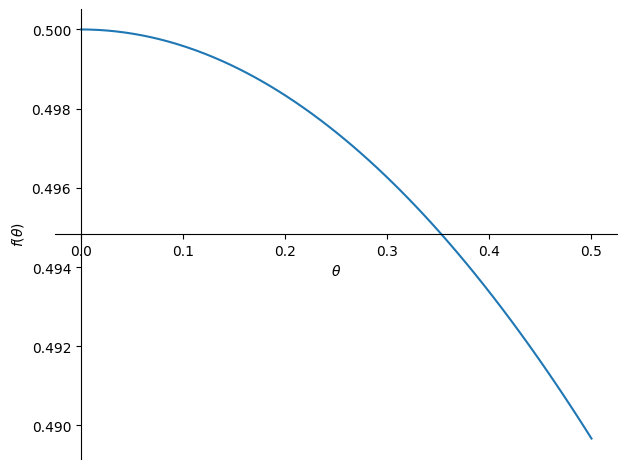

In [59]:
sym.plot(expr_2,(theta,0,1/2))  # 自变量是theta，其取值范围是[0,1/2]

### sympy 应用举例

#### 求极限

$$
\lim_{\theta \to 0} \frac{1-\cos (\theta)}{\theta^2} = ?
$$

In [60]:
sym.limit(expr_2, theta, 0)

1/2

$$
\lim_{x \to +\infty} \frac{\ln x}{x} = ?
$$

In [61]:
sym.limit(sym.log(x)/x, x, +sym.oo)      # sym.oo 无穷大符号

0

#### Taylor 展开

In [62]:
sym.root(x, 3)  # x 的 1/3 次幂

x**(1/3)

$$
\sqrt[3]{\cos(3x)} = ? \quad (x \rightarrow 0)
$$

In [63]:
sym.series(sym.root(sym.cos(3*x), 3),   # 待展开的表达式
            x,      # 待展开的变量
            0,      # 在 x = 0 处展开
            5       # 展开到5阶
        )

1 - 3*x**2/2 - 9*x**4/8 + O(x**5)

$$
\frac{1-\cos x \sqrt{\cos 2 x} \sqrt[3]{\cos 3 x}}{x^2} = ? \quad (x \rightarrow 0)
$$

In [64]:
expr_3 = (1 - sym.root(sym.cos(3*x), 3) * sym.root(sym.cos(2*x), 2) * sym.cos(x)) / x**2

sym.series(expr_3,      # 待展开的表达式
           x,           # 待展开的变量
           0,           # 在 x = 0 处展开
           5            # 展开到5阶
           )

3 - 3*x**2/2 + 49*x**4/30 + O(x**5)

因此，应有：
$$
\lim_{x \to 0} \frac{1-\cos x \sqrt{\cos 2 x} \sqrt[3]{\cos 3 x}}{x^2} = 3
$$

In [65]:
sym.limit(expr_3, x, 0)

3

与上述通过泰勒展开预测的结果一致。

#### 求导和积分

使用`diff()`函数进行求导

In [66]:
sym.diff(expr_2, theta)     # 一阶导数

sin(theta)/theta**2 - 2*(1 - cos(theta))/theta**3

In [67]:
sym.diff(expr_2, theta, 2)  # 二阶导数

(cos(theta) - 4*sin(theta)/theta - 6*(cos(theta) - 1)/theta**2)/theta**2

使用`integrate()`进行积分

In [68]:
sym.integrate(expr_2, theta)

Si(theta) + cos(theta)/theta - 1/theta

用`evalf()`计算符号表达式在特定自变量处的取值

In [69]:
sym.integrate(expr_2, theta).evalf(subs={theta: sym.pi})    # 计算 theta = pi 的函数值

1.21531727961488

用`lambdify()`方法将符号表达式转化为进行数值计算的Python函数

In [70]:
my_func_2 = sym.lambdify(theta, sym.integrate(expr_2, theta))
my_func_2

<function _lambdifygenerated(theta)>

In [71]:
my_func_2(np.pi)

1.2153172796148843

#### 求解微分方程

$$
y'' + y = 1
$$

首先，定义函数符号：

In [72]:
f = sym.Function('y')  

In [73]:
x

x

然后定义微分方程表达式：

In [74]:
my_ode = f(x).diff(x).diff(x) + f(x) - 1
my_ode

y(x) + Derivative(y(x), (x, 2)) - 1

使用`dsolve()`方法求解常微分方程：

In [75]:
sym.dsolve(my_ode)

Eq(y(x), C1*sin(x) + C2*cos(x) + 1)

更多sympy库的使用，可参考：

- sympy文档：https://docs.sympy.org/latest/tutorials/intro-tutorial/features.html 

------

## 3. Matplotlib 可视化简介

- `matplotlib` 是一个用于创建出版物质量图像的绘图工具库, 可在 Python 中实现类似 MATLAB 的绘图界面；
- `matplotlib` 跨平台支持，且可输出常见的矢量图和点阵图格式(PDF、SVG、JPG、PNG、TIFF、GIF 等)；
- 现已衍生出许多使用 `matplotlib` 进行底层绘图的数据可视化附加工具包，如 seaborn 等。

In [2]:
import matplotlib.pyplot as plt

最“简单”的图像：将两个numpy数组分别作为横纵坐标

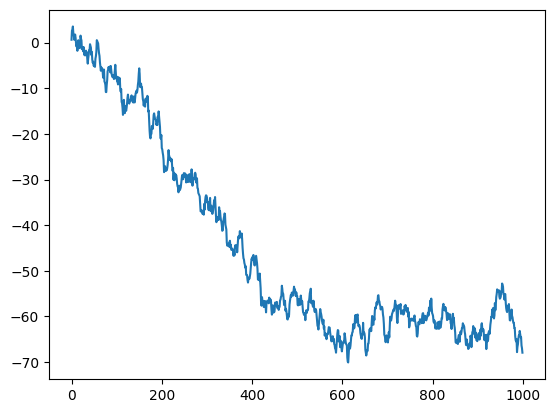

In [77]:
# 准备数据
x = np.arange(1000)
y = np.random.randn(1000).cumsum()

# 绘图
plt.plot(x,y)

线条的颜色和样式可通过参数`[fmt]`调整，其格式为：
`[marker][line][color]`

颜色、线与标记样式与对应符号

| character 	 |  color 	  |
|:-----------:|:---------:|
|    'b' 	    |  blue 	   |
|    'g' 	    |  green 	  |
|    'r' 	    |   red 	   |
|    'c' 	    |  cyan 	   |
|    'm' 	    | magenta 	 |
|    'y' 	    | yellow 	  |
|    'k' 	    |  black 	  |

| marker 	 | description 	           |
|----------|-------------------------|
| 'o' 	    | circle marker 	         |
| 'v' 	    | triangle_down marker 	  |
| '^' 	    | triangle_up marker 	    |
| '<' 	    | triangle_left marker 	  |
| '>' 	    | triangle_right marker 	 |

| line 	 |     description 	     |
|:------:|:---------------------:|
| '-' 	  |  solid line style 	   |
| '--' 	 |  dashed line style 	  |
| '-.' 	 | dash-dot line style 	 |
| ':' 	  |  dotted line style 	  |

例如：红色、圆点、虚线，对应的`[fmt]` 为 `"ro--"`(顺序无要求)

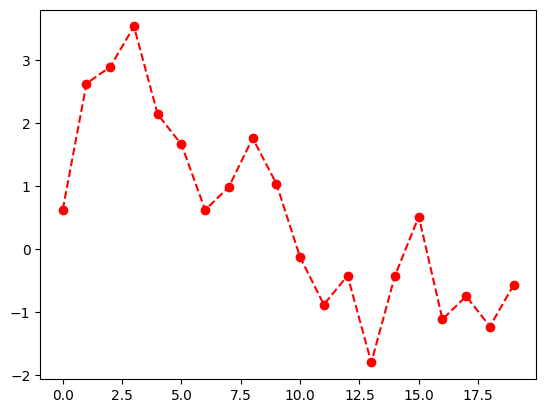

In [78]:
plt.plot(x[:20], y[:20], "ro--")

此外，可以添加元素：
- 坐标轴标签：`xlabel`, `ylabel`
- 图片标题：`title`
- 图例：`legend`

Text(0.5, 1.0, 'Distance v.s. Time')

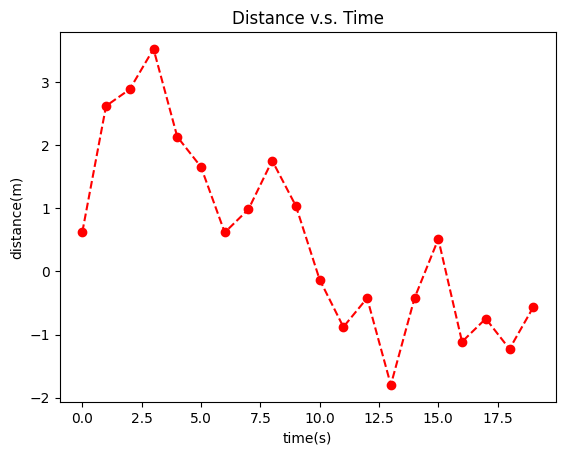

In [79]:
plt.plot(x[:20], y[:20], "ro--")
plt.xlabel("time(s)")
plt.ylabel("distance(m)")
plt.title("Distance v.s. Time")

在添加图例时，需要注意每一条曲线都需添加对应的`label`。例如：

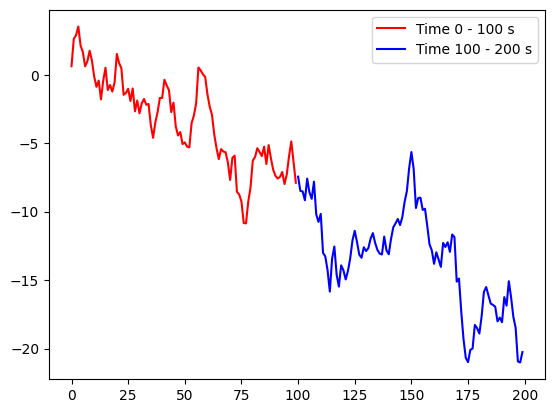

In [80]:
plt.plot(x[:100], y[:100], "r", label="Time 0 - 100 s")
plt.plot(x[100:200], y[100:200], "b", label="Time 100 - 200 s")
plt.legend()

可用`savefig()`方法保存图像到文件中，可指定`dpi`（分辨率，Dot Per Inch）、`bbox_inches`（边缘留白）等参数。例如：

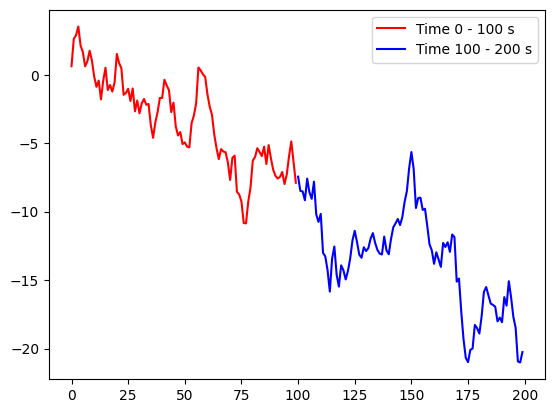

In [81]:
plt.plot(x[:100], y[:100], "r", label="Time 0 - 100 s")
plt.plot(x[100:200], y[100:200], "b", label="Time 100 - 200 s")
plt.legend()
plt.savefig("images/test.jpg", dpi=600, bbox_inches="tight")

### 调整绘图样式

#### 方法1：通过`rcParams`进行调整

`rcParams`中的所有参数选项可参考：https://matplotlib.org/stable/users/explain/customizing.html 

#### 方法2：使用样式文件进行调控

可使用现有的样式文件：
- `matplotlib`自带的样式
- 第三方库（如`scienceplots`等）给出的样式

相关示例代码见`adjust-plot-styles`目录

### 其他二维绘图类型

In [3]:
plt.style.use("mplstyles/science.mplstyle")

#### 示例1：histogram

In [5]:
# 准备数据（正态分布）
mu, sigma = 115, 15
x = mu + sigma * np.random.randn(100000)

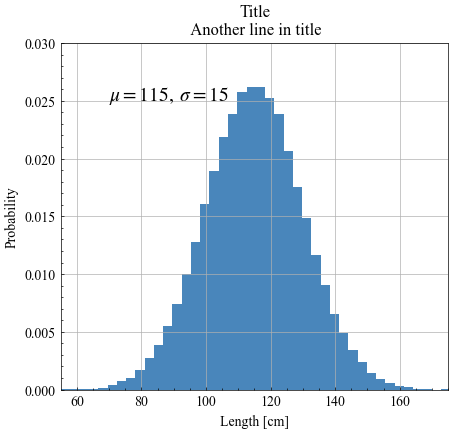

In [6]:
# 创建画布并绘图
plt.figure()
plt.hist(x,                 
            50,             # 将整个区间分为50份
            density=True,   # 采用概率密度分布（即进行归一化处理）
            alpha=0.75      # 条形块的透明度为0.75
        )

plt.xlabel('Length [cm]')
plt.ylabel('Probability')
plt.title('Title\n Another line in title')
plt.text(70, .025,              # 在横坐标70、纵坐标0.025位置处添加文本
    r'$\mu=115,\; \sigma=15$',  # 添加的文本内容（支持latex语法）
    fontdict={'fontsize':14}    # 局部字体设置
    )
plt.xlim([55,175])              # x轴范围设置
plt.ylim([0,0.03])              # y轴范围设置
plt.grid(True, which='major')   # 添加主网格线
plt.savefig('images/hist_example.jpg', dpi=600, bbox_inches='tight')

示例2：contour

In [4]:
data = np.loadtxt('data/test.DAT',skiprows=3)

X = data[:,0]
Y = data[:,1]
Z = data[:,2]

I_zone = 162
J_zone = 82

# 根据读取的数据形成二维数组
X = X.reshape(J_zone,I_zone)
Y = Y.reshape(J_zone,I_zone)
Z = Z.reshape(J_zone,I_zone)

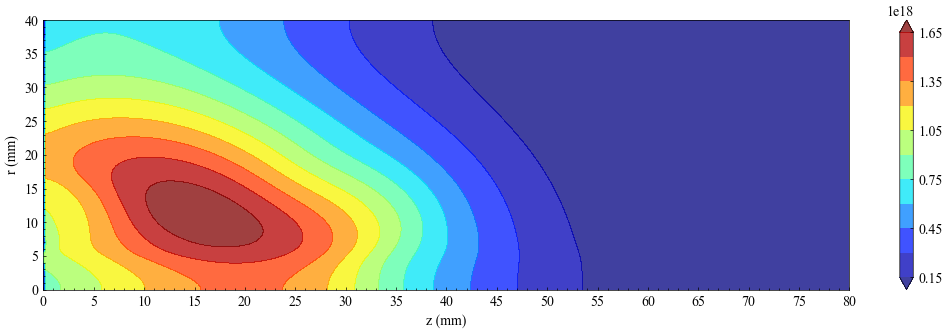

In [5]:
fig = plt.figure(figsize=(13,3.5))
ca = plt.contourf(X * 1e3, Y * 1e3, Z[:,:], 
    cmap='jet',     # 颜色棒的样式
    levels=16,      # 等高线不高于16+1层级
    alpha=0.75,     # 透明度
    extend='both'   # 最小等高线以下以及最大等高线以上的数据也进行着色
)
fig.colorbar(ca)
plt.xlabel('z (mm)')
plt.ylabel('r (mm)')
plt.xticks(np.arange(0,81,5))   # 设置x轴的数字标签
plt.yticks(np.arange(0,41,5))   # 设置x轴的数字标签
plt.savefig("images/contour_example.jpg", dpi=600)

除了等高线图之外，我们也可以通过 `imshow` 函数直接将一个二维数组进行可视化

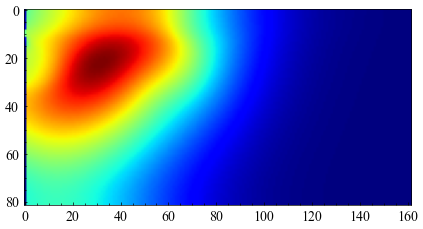

In [10]:
plt.imshow(Z[:,:], cmap='jet')

### 绘制有子图（subplots）的图像

In [9]:
# 准备数据
mu, sigma = 115, 15
x1 = mu + sigma * np.random.randn(100000)

x2 = np.arange(20)
y2 = np.arange(20)/2 + np.random.randn(20)

x3 = np.linspace(-10,10,1000)
T = [2.0, 3.0]
y31, y32 = x3*np.exp(-x3**2/(2*T[0])), x3*np.exp(-x3**2/(2*T[1]))

方法1：显式方法（The explicit "Axes" interface）

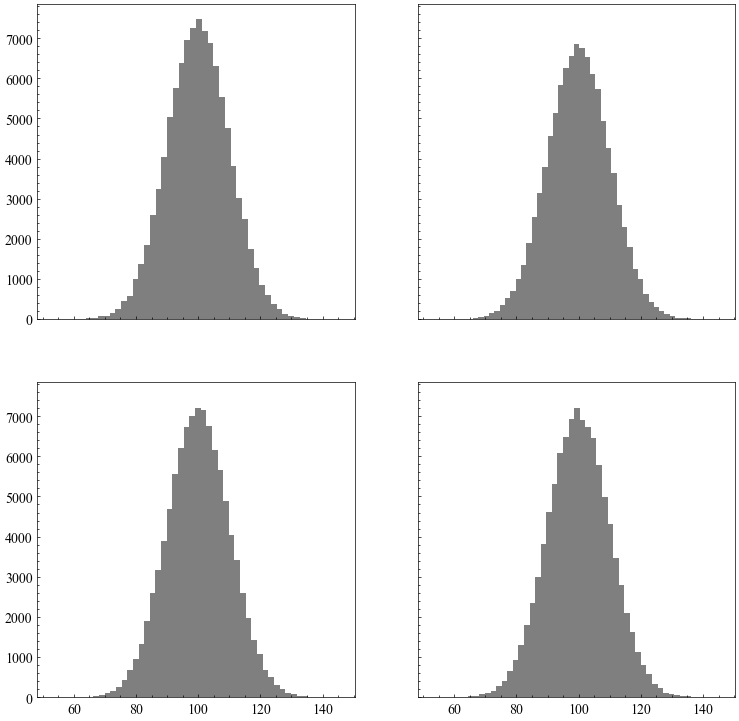

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=2,  # 行数、列数
                         figsize=(9,9),     # 画布大小
                         sharex=True,       # 是否共享x轴
                         sharey=True        # 是否共享y轴
                         )


for i in range(2):
    for j in range(2):
        # 在第i行第j列的子图上 绘制histogram图；i与j都从0开始
        axes[i, j].hist(100+10*(2*i+j+1)*np.random.randn(100000), 
                        bins=50, 
                        color='k', 
                        alpha=0.5)
        
# 保存图像
fig.savefig("images/subplots_example_01.jpg", dpi=600)

方法2：隐式方法（The implicit "pyplot" interface）

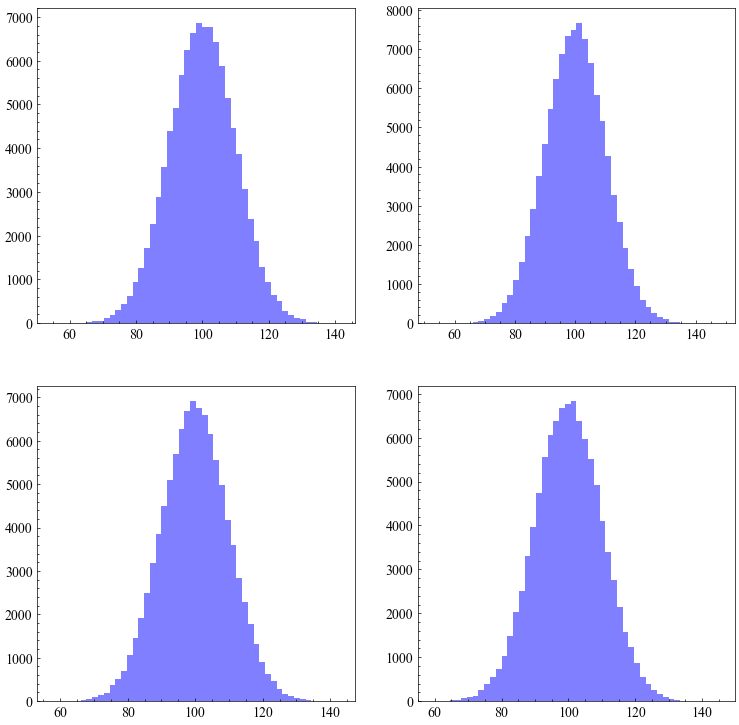

In [14]:
plt.subplots(nrows=2, ncols=2, figsize=(9,9))

for i in range(2):
    for j in range(2):
        plt.subplot(2, 2, 2*i+j+1)  # 指向第(2*i+j+1)个子图，并进行绘制；子图序号从1开始
        plt.hist(100+10*(2*i+j+1)*np.random.randn(100000), 
                        bins=50, 
                        color='b', 
                        alpha=0.5)

# 保存图像到文件
plt.savefig("images/subplots_example_02.jpg", dpi=600)

更多`matplotlib`库的使用方法，可参考：

- matplotlib文档：https://matplotlib.org/stable 
- 参考书：*Python for Data Analysis*

------

## 4. Python 处理 Office 文件简介

首先介绍 Python 处理 Excel 文件。

可使用 `pandas` 库读取 Excel 文件内容，以创建 `DataFrame` 数据结构，然后对其进行处理。

In [1]:
import pandas as pd

可以通过`pd.read_excel()`函数实现从Excel文件读取数据。例如：

In [2]:
df = pd.read_excel("data/input.xlsx")

`df` 的数据类型是 `DataFrame`:

In [3]:
type(df)

pandas.core.frame.DataFrame

`DataFrame`类型有丰富的属性和方法实现数据的分析与处理。例如，可以通过 `info()` 方法查看数据的基本信息：

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   Unnamed: 1  46 non-null     object 
 2   Unnamed: 2  46 non-null     object 
 3   Unnamed: 3  30 non-null     object 
 4   Unnamed: 4  30 non-null     object 
 5   Unnamed: 5  30 non-null     object 
dtypes: float64(1), object(5)
memory usage: 2.3+ KB


可以看到，读取的数据中：
- 共有46个`entry`，涵盖Excel表格的第1行到第46行，再往后的空行没有被读取。实际上，第一行是空行，不需要被读取。可以使用 `skiprows` 参数跳过开头的空行。
- 共有6个`column`，涵盖Excel表格的第1列到第6列，再往右的空列也没有被读取。实际上，第一列是空值，不需要被读取。可以使用 `usecol` 参数只读取指定的列。

In [5]:
df2 = pd.read_excel("data/input.xlsx", 
    usecols = list(range(1,6,1)),   # 只读取第2列到第6列 从0开始计数
    skiprows=1,                     # 跳过第1行
)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   循环次数    45 non-null     int64  
 1   k值      45 non-null     float64
 2   有效循环次数  29 non-null     float64
 3   有效k值    29 non-null     float64
 4   标准差     29 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.9 KB


查看 `df2` 中的数据，发现其中存在许多 `NAN`（缺失值），对应 Excel 表格中的空单元格。

In [14]:
df2

,循环次数,k值,有效循环次数,有效k值,标准差
0,1,1.33046,NaN,NaN,NaN
1,2,1.14452,NaN,NaN,NaN
2,3,1.04172,NaN,NaN,NaN
3,4,1.03145,NaN,NaN,NaN
4,5,1.01381,NaN,NaN,NaN
5,6,0.99366,NaN,NaN,NaN
6,7,0.99074,NaN,NaN,NaN
7,8,0.98049,NaN,NaN,NaN
8,9,1.00622,NaN,NaN,NaN
9,10,0.97792,NaN,NaN,NaN


缺失值可以通过如下方法进行处理，这些方法均会返回处理后的拷贝，而DataFrame本身未改变：
- 通过`isna()`方法判断缺失值的位置
- 通过`fillna()`方法填充缺失值
- 通过`dropna()`方法删除缺失值

In [6]:
df2.isna() 

,循环次数,k值,有效循环次数,有效k值,标准差
0,False,False,True,True,True
1,False,False,True,True,True
2,False,False,True,True,True
3,False,False,True,True,True
4,False,False,True,True,True
5,False,False,True,True,True
6,False,False,True,True,True
7,False,False,True,True,True
8,False,False,True,True,True
9,False,False,True,True,True


In [7]:
df2.fillna(-1)  # df2本身未发生改变 除非使用形如 `df2 = df2.fillna(-1)` 的赋值语句

,循环次数,k值,有效循环次数,有效k值,标准差
0,1,1.33046,-1.0,-1.00000,-1.00000
1,2,1.14452,-1.0,-1.00000,-1.00000
2,3,1.04172,-1.0,-1.00000,-1.00000
3,4,1.03145,-1.0,-1.00000,-1.00000
4,5,1.01381,-1.0,-1.00000,-1.00000
5,6,0.99366,-1.0,-1.00000,-1.00000
6,7,0.99074,-1.0,-1.00000,-1.00000
7,8,0.98049,-1.0,-1.00000,-1.00000
8,9,1.00622,-1.0,-1.00000,-1.00000
9,10,0.97792,-1.0,-1.00000,-1.00000


In [8]:
df2.dropna(axis=0, how='any')

# 参数说明：
# - axis: 0（按行）, 1（按列）
# - how: 'any'（任意一个值为缺失值）, 'all'（所有值为缺失值）

,循环次数,k值,有效循环次数,有效k值,标准差
16,17,0.97793,2.0,0.98945,0.01152
17,18,0.97378,3.0,0.98423,0.00846
18,19,0.98592,4.0,0.98465,0.00600
19,20,0.98767,5.0,0.98525,0.00468
20,21,0.98823,6.0,0.98575,0.00386
21,22,0.97427,7.0,0.98411,0.00365
22,23,0.96126,8.0,0.98125,0.00426
23,24,0.98029,9.0,0.98115,0.00376
24,25,0.98270,10.0,0.98130,0.00336
25,26,0.98063,11.0,0.98124,0.00304


而在读取旧格式Excel文件（`.xls`后缀）时，需用到新版本的`xlrd`引擎；可通过如下命令安装`xlrd`库：
```bash
pip install xlrd[==2.0.1] # 不指定版本则默认安装最新版本
```

In [9]:
df3 = pd.read_excel("data/input.xls", 
    sheet_name = 0,                 # （默认）读取第一个sheet
    usecols = list(range(1,5+1,1)), # 用第2列到第6列
    skiprows = 1,                   # 跳过第1行
)
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   循环次数    45 non-null     int64  
 1   k值      45 non-null     float64
 2   有效循环次数  29 non-null     float64
 3   有效k值    29 non-null     float64
 4   标准差     29 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.9 KB


In [10]:
df3

,循环次数,k值,有效循环次数,有效k值,标准差
0,1,1.33046,NaN,NaN,NaN
1,2,1.14452,NaN,NaN,NaN
2,3,1.04172,NaN,NaN,NaN
3,4,1.03145,NaN,NaN,NaN
4,5,1.01381,NaN,NaN,NaN
5,6,0.99366,NaN,NaN,NaN
6,7,0.99074,NaN,NaN,NaN
7,8,0.98049,NaN,NaN,NaN
8,9,1.00622,NaN,NaN,NaN
9,10,0.97792,NaN,NaN,NaN


可以直接通过列标题名提取数据结构中的一列，并可借助`np.array()`方法转化为数组。例如：

In [12]:
# import numpy as np 
np.array(df3['k值'])

array([1.33046, 1.14452, 1.04172, 1.03145, 1.01381, 0.99366, 0.99074,
       0.98049, 1.00622, 0.97792, 0.99342, 0.96565, 0.99364, 0.96964,
       0.98676, 1.00097, 0.97793, 0.97378, 0.98592, 0.98767, 0.98823,
       0.97427, 0.96126, 0.98029, 0.9827 , 0.98063, 1.0055 , 0.99673,
       0.9668 , 0.98847, 0.99033, 0.97668, 0.98597, 0.98362, 0.98904,
       0.98124, 0.98326, 0.97807, 0.98991, 0.98778, 0.98578, 0.99555,
       0.96203, 0.99304, 0.9836 ])

也可以通过`iloc`获取一整行或一整列。例如：`df3['k值']`的一种等价表示为：

In [13]:
np.array(df3.iloc[:,1])

array([1.33046, 1.14452, 1.04172, 1.03145, 1.01381, 0.99366, 0.99074,
       0.98049, 1.00622, 0.97792, 0.99342, 0.96565, 0.99364, 0.96964,
       0.98676, 1.00097, 0.97793, 0.97378, 0.98592, 0.98767, 0.98823,
       0.97427, 0.96126, 0.98029, 0.9827 , 0.98063, 1.0055 , 0.99673,
       0.9668 , 0.98847, 0.99033, 0.97668, 0.98597, 0.98362, 0.98904,
       0.98124, 0.98326, 0.97807, 0.98991, 0.98778, 0.98578, 0.99555,
       0.96203, 0.99304, 0.9836 ])

In [14]:
np.array(df3.iloc[:,1]) == np.array(df3['k值'])

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

通过`iloc`也可以获取给定索引（需同时给出行索引和列索引）的值。例如，获得数据结构中第20行第2列的值：

In [15]:
df3.iloc[19,1]

0.98767

对`iloc`索引获取的值进行修改，会影响到`DataFrame`本身。例如：

In [16]:
df3.iloc[19,1] = -1
df3

,循环次数,k值,有效循环次数,有效k值,标准差
0,1,1.33046,NaN,NaN,NaN
1,2,1.14452,NaN,NaN,NaN
2,3,1.04172,NaN,NaN,NaN
3,4,1.03145,NaN,NaN,NaN
4,5,1.01381,NaN,NaN,NaN
5,6,0.99366,NaN,NaN,NaN
6,7,0.99074,NaN,NaN,NaN
7,8,0.98049,NaN,NaN,NaN
8,9,1.00622,NaN,NaN,NaN
9,10,0.97792,NaN,NaN,NaN


在完成数据处理后，我们可以通过`pd.to_excel()`方法将DataFrame写入Excel文件中，以便后续数据处理与共享交流。

### 示例：多个 Excel 文件合并：
- 首先，可以将各个Excel表格读取为DataFrame
- 通过`pd.concat()`函数实现两个DataFrame的合并
- 通过`pd.to_excel()`函数将合并后的DataFrame输出到Excel表格

例如，在目录`data/to_be_merged`中，有多个结构相同的Excel文件，文件内容为用户提交的报名表信息。现在需要将多个用户的报名信息合并。

In [20]:
# 列举目录中的所有的 Excel 文件
import glob
excel_file_list = glob.glob("data/to_be_merged/*.xlsx") + glob.glob("data/to_be_merged/*.xls")
excel_file_list

['data/to_be_merged/报名表-3.xlsx',
 'data/to_be_merged/报名表-2.xlsx',
 'data/to_be_merged/报名表-4.xlsx',
 'data/to_be_merged/报名表-1.xlsx']

In [47]:
df_merged = pd.DataFrame()  # 建立一个空的 DataFrame

In [48]:
for excel_file in excel_file_list:
    df = pd.read_excel(excel_file, 
        skiprows=1,
        usecols=range(1,6)
    )

    df_merged = pd.concat([df_merged, df], ignore_index=True)

In [49]:
df_merged

,姓名,学号,院系,成绩,备注
0,马尔福,2024666990,斯莱特林,3.80,NaN
1,斯内普,2333666996,斯莱特林,4.00,NaN
2,伏地魔,2333666999,NaN,-1.00,You know who
3,迪戈里,2024998887,赫奇帕奇,3.88,NaN
4,哈利,2024999666,格兰芬多,3.90,无
5,赫敏,2024999667,格兰芬多,3.95,NaN


用 `to_excel()` 方法将合并后的DataFrame保存到文件 `data/merged.xlsx` 中：

In [52]:
df_merged.to_excel("data/merged_v1.xlsx")

默认情况下，列索引作为表格的首行，行索引作为表格的首列，缺失值在Excel表格中对应空单元格。
如下图所示。

<img src="./images/merged-v1-screenshot.jpg" width="80%">

如果不想在输出的Excel文件中保留没有实际意义的行索引，可以通过`index=None`进行设置。

In [51]:
df_merged.to_excel("data/merged_v2.xlsx", index=None)

输出的Excel文件如下图所示。

<img src="./images/merged-v2-screenshot.jpg" width="80%">

更多`pandas`库的用法，可参考：

- `pandas` 官方文档：https://pandas.pydata.org/pandas-docs/stable/index.html
- 参考书：*Python for Data Analysis*, Chapter 5 & Chapter 8

其余 Office 文件的处理，可以使用 `python-docx`（Word文档）、`python-pptx`（PPT文档）、`python-office`（综合办公应用）等第三方库。

------

## 5. Python 处理网络数据简介

Python 爬取网络数据有多种方式，此处仅简要介绍通过API的方式获得网络上的数据。

在API(application programming
interface, 应用程序接口)调用方式中，我们获取的往往并非整个网页，而是更容易处理的数据结构（如JSON、CSV等）。

我们可以通过官方的或者“野生”的API调用进行网络数据的获取与分析。
部分Github或Gitee项目给出了常见的API接口的汇总，可供参考：例如 [public-apis](https://github.com/public-apis/public-apis), [free-api](https://gitee.com/fahawifi/free-api) 等等。
可使用 [API-Fox](https://app.apifox.com), [Postman](https://www.postman.com/) 等工具辅助进行API分析与调试。 

### 示例1: 获取GitHub中star数最多的Python项目

首先，尝试在浏览器中打开如下链接：

https://api.github.com/search/repositories?q=language:python&sort=stars

我们可以获得一个庞大的“字典”数据。关于上述GitHub的API调用，可参考[此链接](https://docs.github.com/zh/rest/search/search?apiVersion=2022-11-28#search-repositories)。

我们也可以通过 `requests` 库自动地获取这一数据。

In [1]:
import requests

In [2]:
url = "https://api.github.com/search/repositories"
url += "?q=language:python+sort:stars+stars:>10000"

# 模拟浏览器请求
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/130.0.0.0 Safari/537.36 Edg/130.0.0.0"}

In [3]:
r = requests.get(url, headers=headers)

In [4]:
print(f"Status code: {r.status_code}")

Status code: 200


常见 status code（状态码）及其含义说明：

| Status Code | 含义                                      |
|-------------|------------------------------------------|
| 100         | Continue - 继续处理下一部分请求          |
| 200         | OK - 请求成功，并且服务器返回了请求的数据   |
| 201         | Created - 请求成功，并且服务器创建了新的资源 |
| 301         | Moved Permanently - 请求的资源已被永久移动到新位置 |
| 302         | Found - 请求的资源临时移动到另一个URI   |
| 304         | Not Modified - 自从上次请求后，请求的资源未修改 |
| 400         | Bad Request - 服务器无法理解请求，通常是因为客户端请求有语法错误 |
| 401         | Unauthorized - 请求要求用户的身份验证     |
| 403         | Forbidden - 服务器理解请求客户端的请求，但是拒绝执行此请求 |
| 404         | Not Found - 服务器找不到请求的网页        |
| 500         | Internal Server Error - 服务器遇到错误，无法完成请求 |


可以提取从网络获得的响应中的数据，并进行分析和处理：

In [5]:
response_dict = r.json()

print(f"Total repositories: {response_dict['total_count']}")
print(f"Complete results: {not response_dict['incomplete_results']}")

Total repositories: 555
Complete results: True


In [6]:
repo_dicts = response_dict['items']
print(f"The number of repositories returned is {len(repo_dicts)}")     

The number of repositories returned is 30


返回的项目仓库只有30个，这是因为默认的请求参数`per_page`为30；可修改此参数获得更多的返回结果。

接下来，将数据提取并输出到Excel文件中：

In [10]:
# import pandas as pd

data = [
    {
        '名称': repo_dict['name'],
        '作者': repo_dict['owner']['login'],
        'star数': repo_dict['stargazers_count'],
        '链接': repo_dict['html_url'],
        '更新时间': repo_dict['updated_at'],
        '项目描述': repo_dict['description']
    }
    for repo_dict in repo_dicts
]

df = pd.DataFrame(data)
df.to_excel("results.xlsx", index=None)

输出的Excel文件截图如下图所示。

<img src="images/github-api-results-screenshot.jpg" width=95%>

### 示例2: 清华云盘文件批量下载

原项目地址：https://github.com/zqthu/thu_cloud_download

讲师略作修改，考虑了文件或目录存在空格、加号（+）等特殊符号的情况，将 'file_path' 等参数进行了转化。

适用情况（之一）：分享链接为目录类型，且文件较多，无法“zip”打包下载。

<img src="images/size-too-large-prompt.jpg" >

In [21]:
# 下载
import requests
import json
import os
import re
import urllib.parse

class THUCloud():
    def __init__(self, shared_link, outdir=None):
        self.headers={"User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/80.0.3987.132 Safari/537.36"}

        if "/f/" in shared_link: # single file
            self.is_dir = False
            archive = shared_link.split("/f/")[-1].split("/")[0]
            self.api_link = "https://cloud.tsinghua.edu.cn/f/{}/".format(archive)
            self.file_link = "https://cloud.tsinghua.edu.cn/f/{}/?dl=1".format(archive)
        elif '/d/' in shared_link: # dir
            self.is_dir = True
            archive = shared_link.split("/d/")[-1].split("/")[0]
            self.api_link = "https://cloud.tsinghua.edu.cn/api/v2.1/share-links/{}/dirents/".format(archive)
            self.file_link = "https://cloud.tsinghua.edu.cn/d/{}/files/".format(archive)
        else:
            raise ValueError("Cannot parse the shared link.")

        if outdir is None:
            self.current_dir = os.getcwd()
        else:
            self.current_dir = os.path.abspath(outdir)
        if not os.path.exists(self.current_dir):
            os.mkdir(self.current_dir)

    def _move_to(self, to_dir):
        self.current_dir = os.path.abspath(os.path.join(self.current_dir, to_dir))
        # print(self.current_dir)
        if not os.path.exists(self.current_dir):
            os.mkdir(self.current_dir)

    def _parse_url(self, path):
        url = self.api_link + '?path={}'.format(path)
        # print("url = {}".format(url))
        response = requests.get(url=url, headers=self.headers)
        assert response.status_code == 200
        return response.content.decode()

    def _retrieve_file(self, url, name): # for small files
        file_path = os.path.join(self.current_dir, name)
        response = requests.get(url=url, headers=self.headers)
        assert response.status_code == 200
        content = response.content
        with open(file_path, "wb") as f:
            f.write(content)
        print("Downloaded file: {}".format(name))

    def _recursion_download(self, path):
        # print(path)
        response = self._parse_url(path)
        response_dict = json.loads(response)
        # print(response_dict)
        for item in response_dict['dirent_list']:
            # Modified by flying pointer2, 20251205
            if item['is_dir'] == True:
                next_path = urllib.parse.quote(item['folder_path'], safe='')
                print("\nGo to folder: {}".format(item['folder_name']))
                self._move_to(item['folder_name'])
                self._recursion_download(next_path)
            else:
                item_file_path = urllib.parse.quote(item['file_path'], safe='')
                url = self.file_link + '?p=' + item_file_path + '&dl=1'
                self._retrieve_file(url, item['file_name'])
        self._move_to("..")

    def download(self):
        if self.is_dir:
            self._recursion_download("/") # initial data, default download all files
            # TODO: support download list, block list and regex pattern
        else:
            response = requests.get(url=self.api_link, headers=self.headers)
            assert response.status_code == 200
            content = response.content.decode()
            name = re.search(r"fileName: '(.*)',", content).group(1)
            self._retrieve_file(self.file_link, name)

In [ ]:
# 测试
# 测试下载链接：https://cloud.tsinghua.edu.cn/d/ca580d935f4e4302a0dd/
# 测试下载时间：3分30秒

shared_link = input('Please input the shared link: ')
out_dir = "download"

t = THUCloud(shared_link, out_dir)
t.download()

请填写反馈问卷：

<img src="images/qr-code.png" width=50%>